In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [9]:
path = r'E:\E-commerce Analysis\Data\processed\performance_produto_tratada.csv'

In [12]:
df = pd.read_csv(path)

In [13]:
df.head()

,product_id,product_category_name,quantidade_vendida,receita_total
0,bb50f2e236e5eea0100680137654686c,beleza_saude,195,"63,885.00"
1,6cdd53843498f92890544667809f1595,beleza_saude,156,"54,730.20"
2,d6160fb7873f184099d9bc95e30376af,pcs,35,"48,899.34"
3,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,343,"47,214.51"
4,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,488,"43,025.56"


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             32951 non-null  str    
 1   product_category_name  32951 non-null  str    
 2   quantidade_vendida     32951 non-null  int64  
 3   receita_total          32951 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.0 MB


In [15]:
pd.options.display.float_format = '{:,.2f}'.format

In [16]:
df['receita_total'].sum()

np.float64(13591643.701720357)

In [17]:
df.isnull().sum()

product_id               0
product_category_name    0
quantidade_vendida       0
receita_total            0
dtype: int64

In [19]:
df.sort_values(by='quantidade_vendida', ascending=False)

,product_id,product_category_name,quantidade_vendida,receita_total
9,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,527,"37,608.90"
4,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,488,"43,025.56"
16,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484,"26,577.22"
24,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392,"21,440.59"
25,368c6c730842d78016ad823897a372db,ferramentas_jardim,388,"21,056.80"
...,...,...,...,...
32942,c2fb26742f8484dbfe9a8d70bdc54025,informatica_acessorios,1,3.90
32941,836c4b48c2b383bb38bb5788f828c596,fashion_underwear_e_moda_praia,1,3.90
32940,eee2fb3dceb9ffd8a99dd4bc4b7e860a,informatica_acessorios,1,3.90
32939,66389c9df136a25c8f131757ce3a6967,construcao_ferramentas_construcao,1,3.99


In [20]:
df.sort_values(by='receita_total', ascending=False)

,product_id,product_category_name,quantidade_vendida,receita_total
0,bb50f2e236e5eea0100680137654686c,beleza_saude,195,"63,885.00"
1,6cdd53843498f92890544667809f1595,beleza_saude,156,"54,730.20"
2,d6160fb7873f184099d9bc95e30376af,pcs,35,"48,899.34"
3,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,343,"47,214.51"
4,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,488,"43,025.56"
...,...,...,...,...
32946,2e8316b31db34314f393806fd7b6e185,papelaria,1,2.99
32947,680cc8535be7cc69544238c1d6a83fe8,pet_shop,1,2.90
32948,8a3254bee785a526d548a81a9bc3c9be,construcao_ferramentas_construcao,3,2.55
32949,310dc32058903b6416c71faff132df9e,papelaria,1,2.29


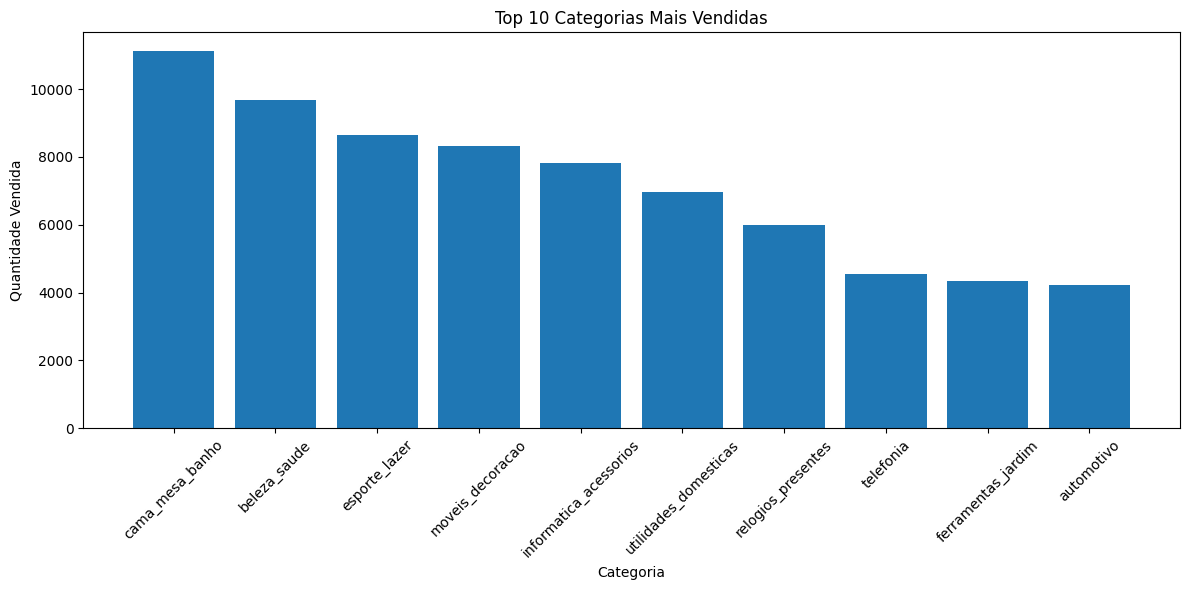

In [25]:
# Gráfico de barras para as 10 categorias mais vendidas
top_10_categorias = (
    df.groupby('product_category_name')['quantidade_vendida']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.bar(top_10_categorias.index, top_10_categorias.values)
plt.title('Top 10 Categorias Mais Vendidas')
plt.xlabel('Categoria')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

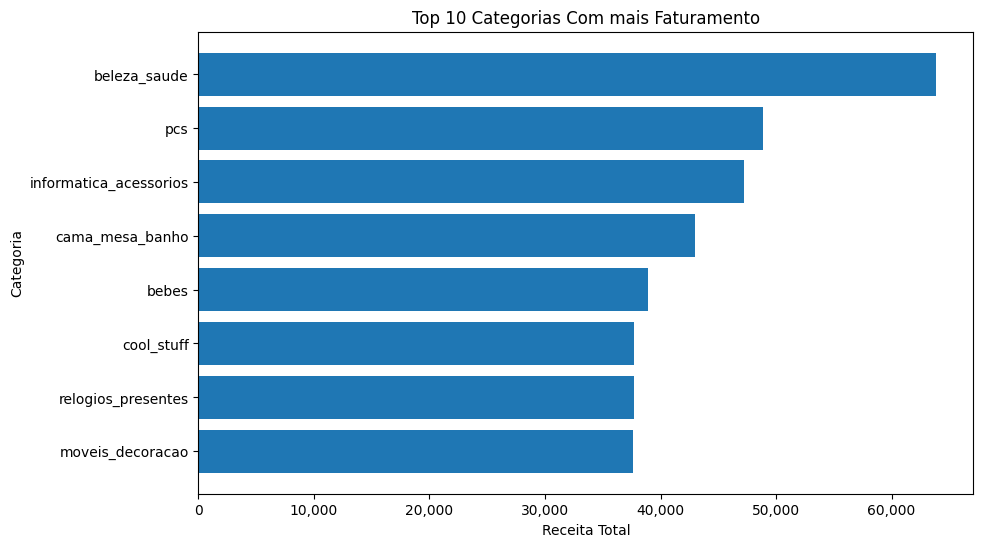

In [26]:
top10_categoria = df.sort_values('receita_total', ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top10_categoria['product_category_name'], top10_categoria['receita_total'])

plt.title('Top 10 Categorias Com mais Faturamento')
plt.xlabel('Receita Total')
plt.ylabel('Categoria')

plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()